<a href="https://colab.research.google.com/github/tdineth/Image-Processing-CO5430-4th-sem/blob/main/lab03/E_23_076_Lab_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 1 — Simulate Salt-and-Pepper Noise

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
face_path = "/content/drive/MyDrive/Image Processing - CO5430 - 4th sem/lab3/lena.png"

In [ ]:
def show_image(title, img):
    plt.figure()
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
img = cv2.imread(face_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

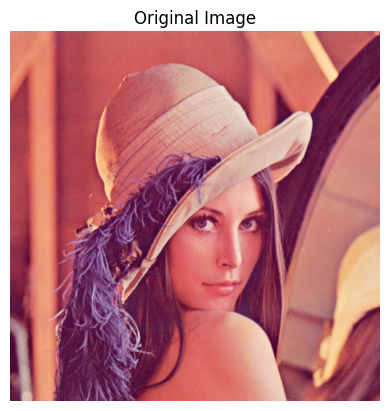

In [ ]:
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

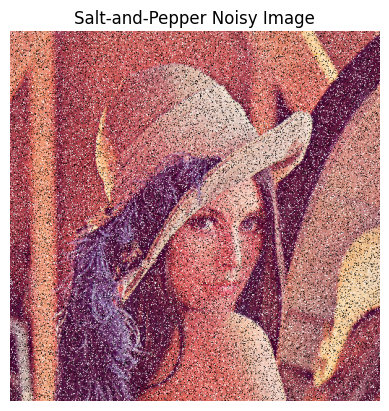

In [ ]:
noisy = img.copy()

prob = 0.1
# This means 10% of pixels become salt and 10% become pepper.
# So overall, 20% of the image becomes corrupted.

# Salt (white pixels)
salt_mask = np.random.rand(*img.shape[:2]) < prob
noisy[salt_mask] = 255

# Pepper (black pixels)
pepper_mask = np.random.rand(*img.shape[:2]) < prob
noisy[pepper_mask] = 0

plt.imshow(noisy)
plt.title("Salt-and-Pepper Noisy Image")
plt.axis('off')
plt.show()

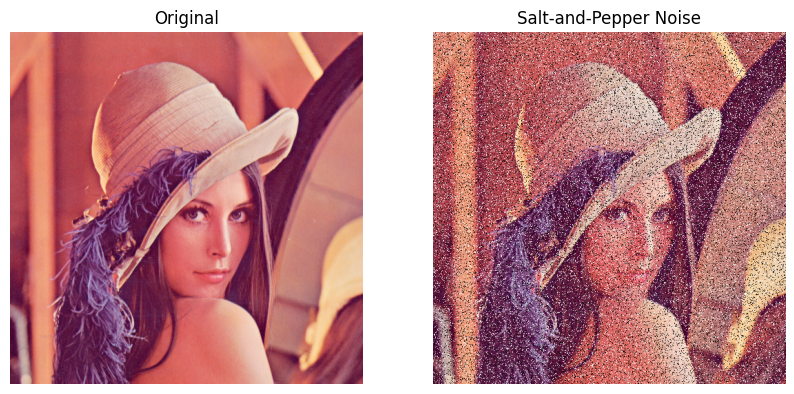

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(noisy)
ax[1].set_title("Salt-and-Pepper Noise")
ax[1].axis('off')

plt.show()

**How does noise disrupt fine facial structure?**

Salt-and-pepper noise introduces random black and white pixels into the image. These pixels interfere with facial features such as eyes, eyebrows, lips, skin texture and hair boundaries. As a result, important details become harder to distinguish and the overall image quality decreases.

**Why does randomness break visual continuity?**

Natural images contain smooth intensity variations and consistent patterns. Random noise introduces sudden intensity changes that do not belong to the actual scene. These abrupt changes interrupt the continuity of structures and make the image appear distorted.

**Why is random noise more damaging than uniform blur?**

Random noise creates unpredictable pixel values that can completely hide important details and edges. Uniform blur, on the other hand, smooths neighboring pixels consistently. Although blur reduces sharpness, the overall structure of objects remains recognizable. Therefore, random noise is generally more destructive to visual interpretation than uniform blur.

### Task 2 — Apply Mean Filter

In [ ]:
noisy = cv2.imread("/content/drive/MyDrive/Image Processing - CO5430 - 4th sem/lab3/Sample image.jpg")
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

In [ ]:
mean = cv2.blur(noisy, (3,3))

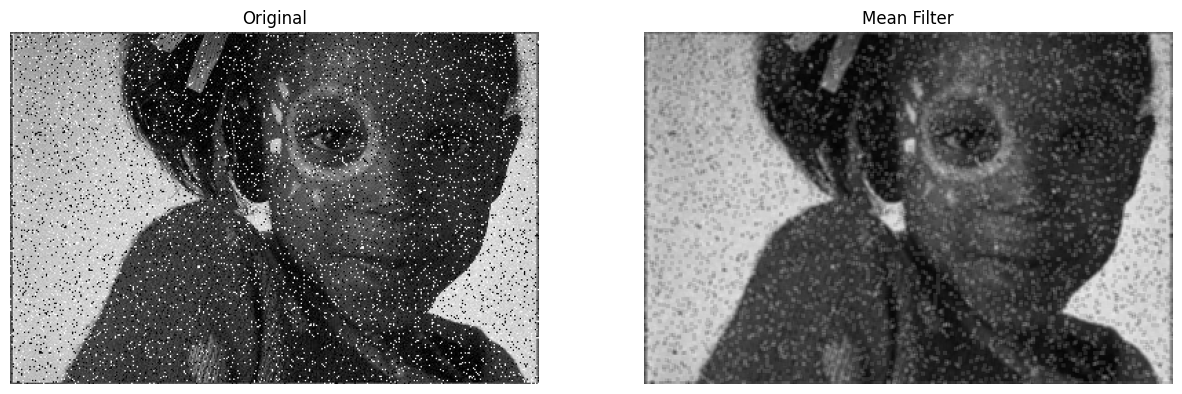

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(noisy)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mean)
plt.title("Mean Filter")
plt.axis('off')

plt.show()

**Why does the image become blurry?**

The mean filter replaces each pixel with the average value of its neighboring pixels. This averaging smooths sudden intensity variations caused by noise. However, it also smooths genuine image details, causing the image to appear blurry.

**Why does naive smoothing destroy edge sharpness?**

Edges are regions with large intensity differences between neighboring pixels. The mean filter averages pixels across these boundaries, reducing the contrast at edges and making them appear less sharp.

**Why is blurring sometimes acceptable in low-detail backgrounds?**

Background regions often contain fewer important features than foreground objects. Slight blurring can reduce noise in these areas without significantly affecting visual perception. Therefore, some loss of detail in the background is usually acceptable if it improves overall image quality.

### Task 3 — Median Filter for Salt-Pepper


In [ ]:
median = cv2.medianBlur(noisy, 3)

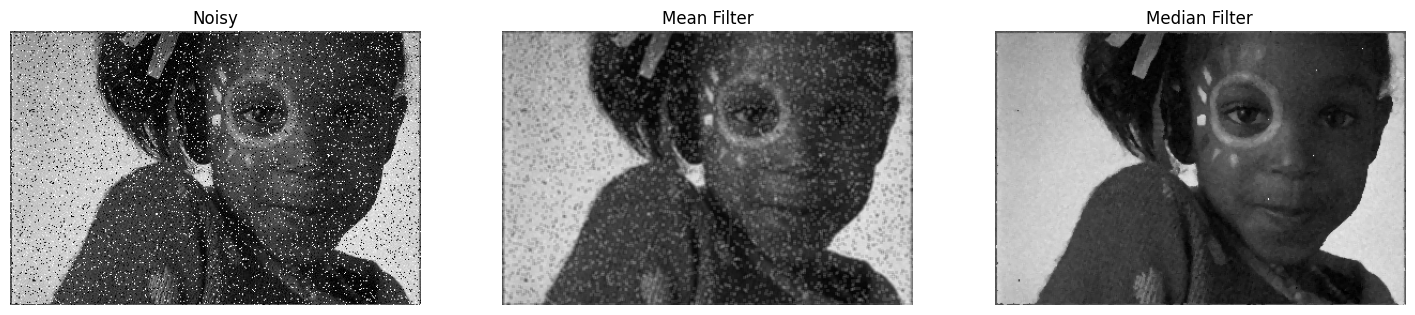

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mean, cmap='gray')
plt.title("Mean Filter")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(median, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.show()

**How does the median filter preserve edges?**

The median filter replaces a pixel with the median value of its neighborhood rather than the average. Since the median is less affected by extreme noisy pixels, edges remain sharper while isolated noise points are removed.

**Why does the median filter eliminate impulses more effectively?**

Salt-and-pepper noise appears as extreme pixel values (0 or 255). The median operation ignores these outliers when selecting the middle value, making it highly effective for removing impulse noise.

**Why does median treat noise differently from mean?**

The mean filter uses all pixel values, including noisy outliers, when computing the average. The median filter selects the middle value after sorting the neighborhood pixels, making it resistant to extreme noise values and better at preserving image structure.

### Task 4 — Gaussian Smoothing

In [ ]:
gauss = cv2.GaussianBlur(noisy, (5,5), 1)

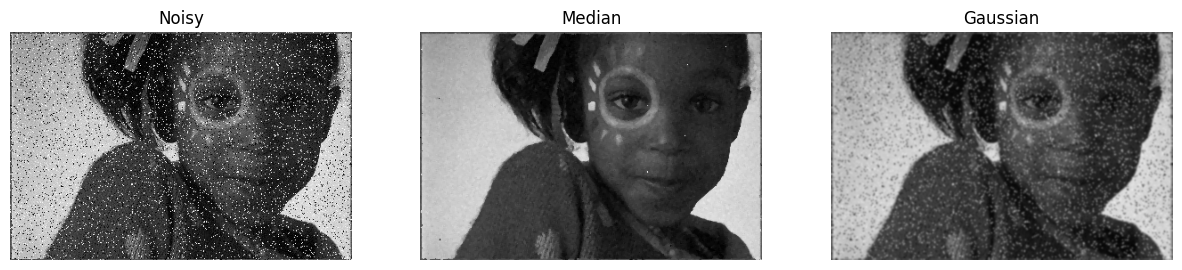

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(median, cmap='gray')
plt.title("Median")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussian")
plt.axis('off')

plt.show()

**Trade-off Between Noise Reduction and Structural Loss**

Gaussian smoothing reduces image noise by averaging neighboring pixel values using a weighted Gaussian distribution. While this improves smoothness and reduces some noise, it also blurs edges and removes fine image details. Increasing the amount of smoothing improves noise reduction but causes greater structural loss. Therefore, a balance must be maintained between removing noise and preserving important facial features.

**Why does Gaussian blur feel visually "natural"?**

Gaussian blur gives higher weights to nearby pixels and lower weights to distant pixels. This produces smooth intensity transitions that resemble natural optical blur and human visual perception. As a result, Gaussian smoothing often appears more natural than simple averaging.

### Task 4.1 — Effect of Filter Size

In [ ]:
g3 = cv2.GaussianBlur(noisy,(3,3),1)
g5 = cv2.GaussianBlur(noisy,(5,5),1)
g9 = cv2.GaussianBlur(noisy,(9,9),1)

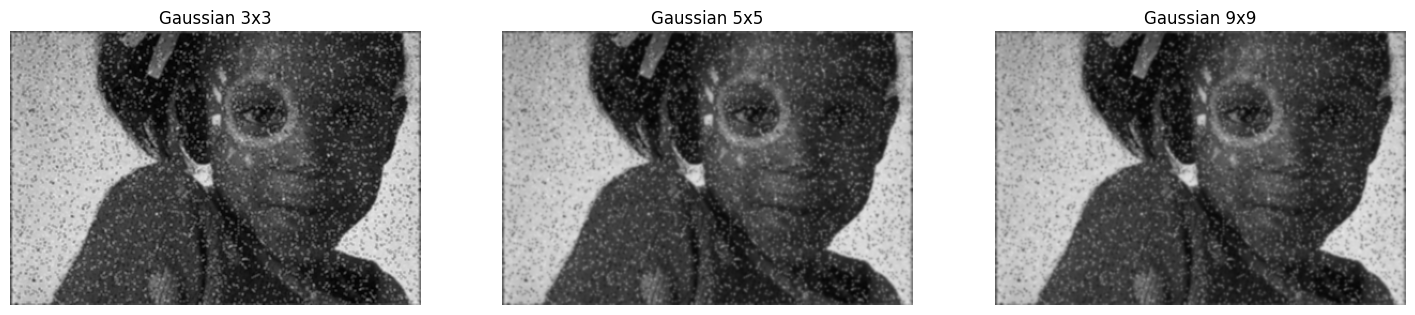

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(g3, cmap='gray')
plt.title("Gaussian 3x3")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(g5, cmap='gray')
plt.title("Gaussian 5x5")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(g9, cmap='gray')
plt.title("Gaussian 9x9")
plt.axis('off')

plt.show()

**Compare the outputs and comment on:**
- **Noise reduction**
- **Edge preservation**
- **Detail loss**

**1. Noise Reduction**

**Gaussian 3×3**

- Small amount of smoothing.
- Most noise remains visible.
- Weak noise reduction.

**Gaussian 5×5**

- More smoothing than 3×3.
- Slight reduction in noise.
- Some image details start to soften.

**Gaussian 9×9**

- Strongest smoothing.
- More noise suppression.
- Significant loss of fine details.

***Conclusion***

- Noise reduction increases as kernel size increases.

**2. Edge Preservation**

**Gaussian 3×3**

- Best edge preservation.
- Facial boundaries remain relatively sharp.

**Gaussian 5×5**

- Moderate edge preservation.
- Edges begin to blur.

**Gaussian 9×9**

- Noticeable edge degradation.
- Boundaries become less distinct.

***Conclusion***

- Edge preservation decreases as kernel size increases.

**3. Detail Loss**

**Gaussian 3×3**

- Minimal detail loss.

**Gaussian 5×5**

- Moderate detail loss.

**Gaussian 9×9**

- Significant detail loss.
- Small facial textures become difficult to distinguish.

***Conclusion***

- Detail loss increases with kernel size.

**Why does increasing kernel size eventually destroy useful image information?**

A larger Gaussian kernel averages pixel values over a wider neighborhood. While this removes more noise, it also smooths important image structures such as edges, textures and fine details. Excessive smoothing causes different regions of the image to blend together, resulting in loss of useful information and reduced visual quality.

### Task 5 — Bilateral Filtering for Edge Preservation

In [ ]:
bil = cv2.bilateralFilter(noisy, 9, 60, 60)

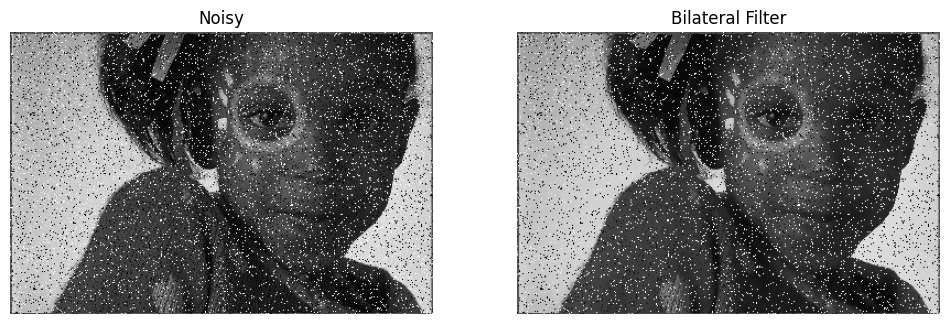

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(bil, cmap='gray')
plt.title("Bilateral Filter")
plt.axis('off')

plt.show()

**How does preserving edge discontinuities keep facial identity intact?**

Facial identity depends on important structural features such as the eyes, nose, mouth, and face contours. Bilateral filtering smooths pixels within similar intensity regions while avoiding averaging across edges. As a result, important facial boundaries remain sharp, helping preserve the person's appearance and identity.

**Why are edge-aware filters more computationally expensive?**

Traditional filters such as mean and Gaussian use only spatial distance when computing pixel values. Bilateral filtering considers both spatial distance and intensity similarity. For every pixel, additional calculations must be performed to determine how similar neighboring pixels are. These extra computations increase processing time and computational cost.

### Task 5.1 — Compare Filtering Results

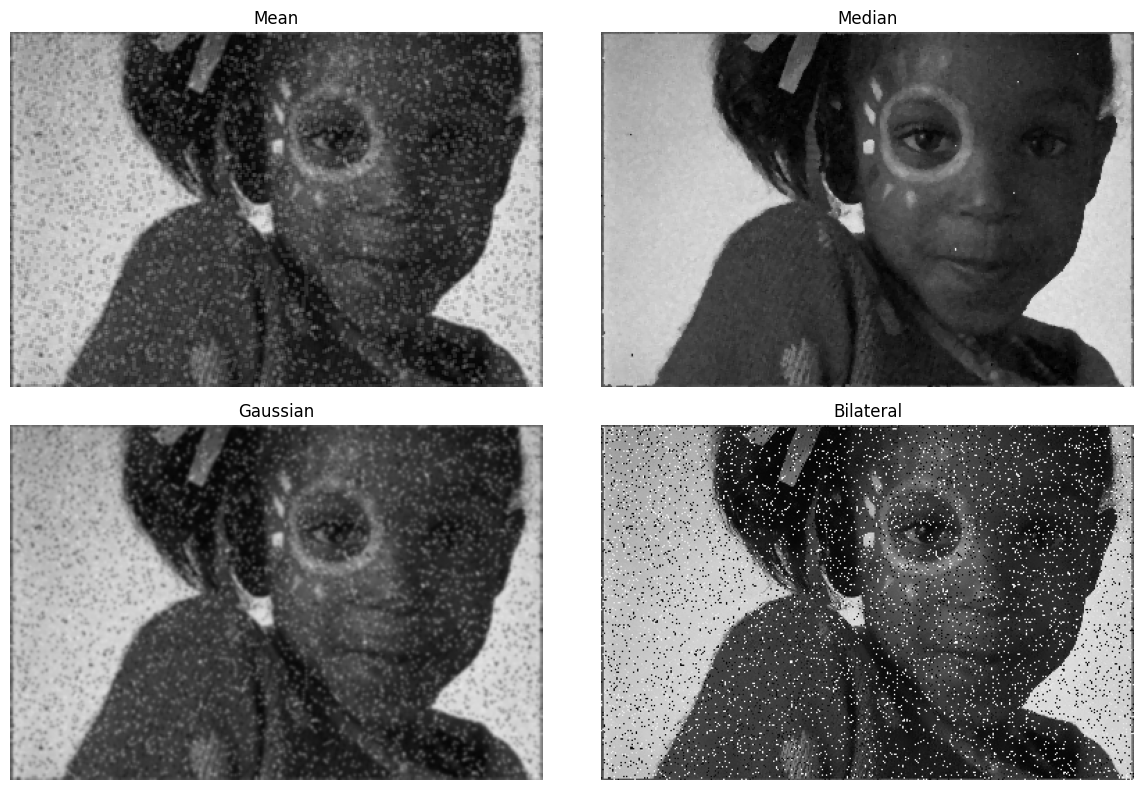

In [ ]:
images = [mean, median, gauss, bil]
titles = ["Mean", "Median", "Gaussian", "Bilateral"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

| Filter    | Noise Removal | Edge Preservation | Visual Quality |
| --------- | ------------- | ----------------- | -------------- |
| Mean      | Medium        | Poor              | Fair           |
| Median    | Very Good     | Good              | Good           |
| Gaussian  | Good          | Moderate          | Good           |
| Bilateral | Excellent     | Excellent         | Excellent      |


Ranking
1. Bilateral
2. Median
3. Gaussian
4. Mean

**Can the best filter for one image always be best for another?**

No. Different images contain different noise types and detail levels.

### Task 6 — Laplacian Sharpening

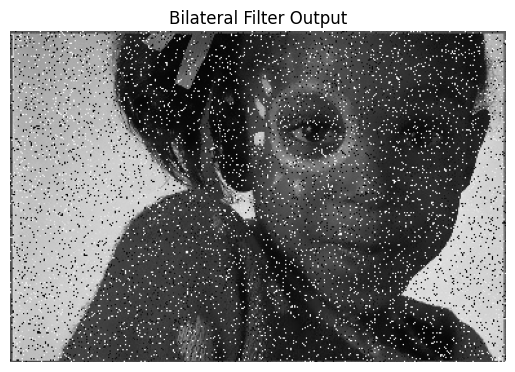

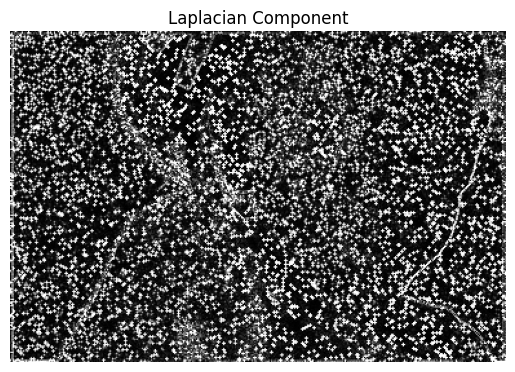

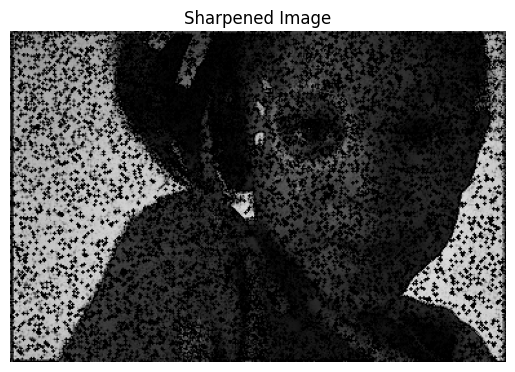

In [ ]:
# Laplacian Sharpening

lap = cv2.Laplacian(bil, cv2.CV_64F)
lap = cv2.convertScaleAbs(lap)

sharp = cv2.subtract(bil, lap)

show_image("Bilateral Filter Output", bil)
show_image("Laplacian Component", lap)
show_image("Sharpened Image", sharp)

**How sharpening emphasizes structural boundaries but can re-magnify noise if misused**


- Structural Boundaries

The sharpened image shows clearer boundaries around facial features such as the eyes, nose, lips and hair. Fine details become more prominent.

- Effect on Noise

If the image still contains noise, sharpening may also enhance that noise because noise contains high-frequency components similar to edges.

- Visual Quality

Applying Laplacian sharpening after bilateral filtering produces a sharper and cleaner image while maintaining natural appearance.


**Can sharpening fully recover high-frequency details lost during filtering?**

No. Sharpening can enhance existing edges and details, but it cannot completely restore information that has already been removed during filtering. Once image details are lost, they cannot be perfectly reconstructed by sharpening alone.

### Task 6.1 — When Should Sharpening Be Applied?

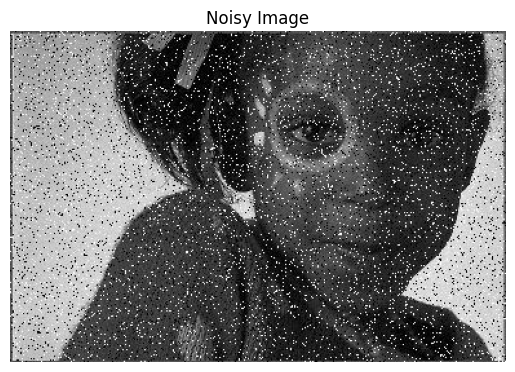

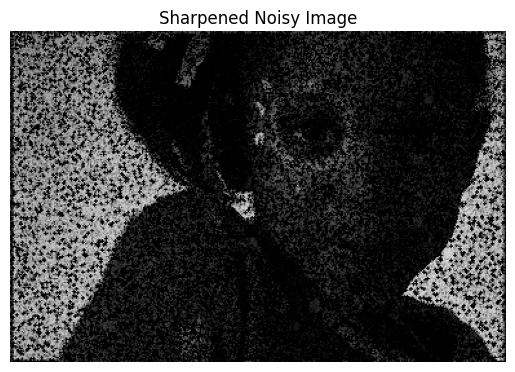

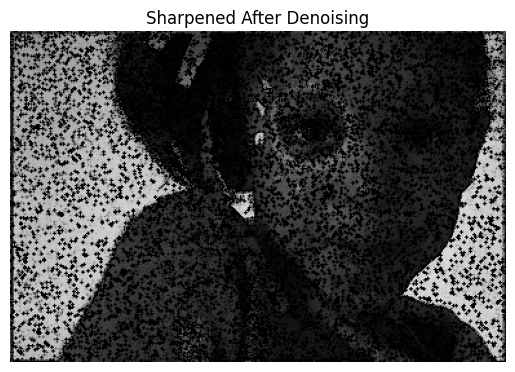

In [ ]:
# Sharpening the noisy image

lap_noisy = cv2.Laplacian(noisy, cv2.CV_64F)
lap_noisy = cv2.convertScaleAbs(lap_noisy)

sharp_noisy = cv2.subtract(noisy, lap_noisy)

show_image("Noisy Image", noisy)
show_image("Sharpened Noisy Image", sharp_noisy)
show_image("Sharpened After Denoising", sharp)

1. **Noise Amplification**

- Sharpening Before Denoising (sharp_noisy):

Noise becomes much more visible.
Salt-and-pepper pixels are enhanced together with edges.
The image appears rough and grainy.

- Sharpening After Denoising (sharp):

Most noise has already been removed.
Sharpening mainly enhances real image structures.
Cleaner appearance.

2. **Edge Enhancement**

- Before Denoising

Edges are enhanced.
Noise pixels may be mistaken for edges.

- After Denoising

Real facial boundaries are enhanced.
Edge enhancement is more accurate and visually pleasing.

3. Visual Quality

| Method                  | Visual Quality |
| ----------------------- | -------------- |
| Sharpen Noisy Image     | Poor           |
| Sharpen After Denoising | Good           |


The image sharpened after denoising has better clarity and less distraction from noise.

**Why is sharpening usually performed after noise removal?**

Sharpening increases high-frequency components in an image. Since noise is also a high-frequency component, applying sharpening directly to a noisy image amplifies both edges and noise. Denoising first removes unwanted high-frequency noise, allowing sharpening to enhance only meaningful structures and edges. Therefore, sharpening after denoising produces significantly better visual quality

### Final Reflection

**Write one paragraph describing the balance between denoising and detail retention. Which filter produced the best compromise and why?**

Image denoising requires a careful balance between removing unwanted noise and preserving important image details. Filters such as the mean and Gaussian filters effectively reduce noise but tend to blur edges and fine structures. The median filter performs better for salt-and-pepper noise because it removes impulse noise while preserving edges. Among all the tested methods, the bilateral filter provided the best compromise between noise reduction and detail retention. It successfully smoothed noisy regions while preserving important facial boundaries and textures. This resulted in the highest visual quality and the most natural appearance. Therefore, the bilateral filter was the most suitable choice for this image because it achieved strong noise removal without sacrificing significant structural information